Common Lib import

In [23]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

Question 1

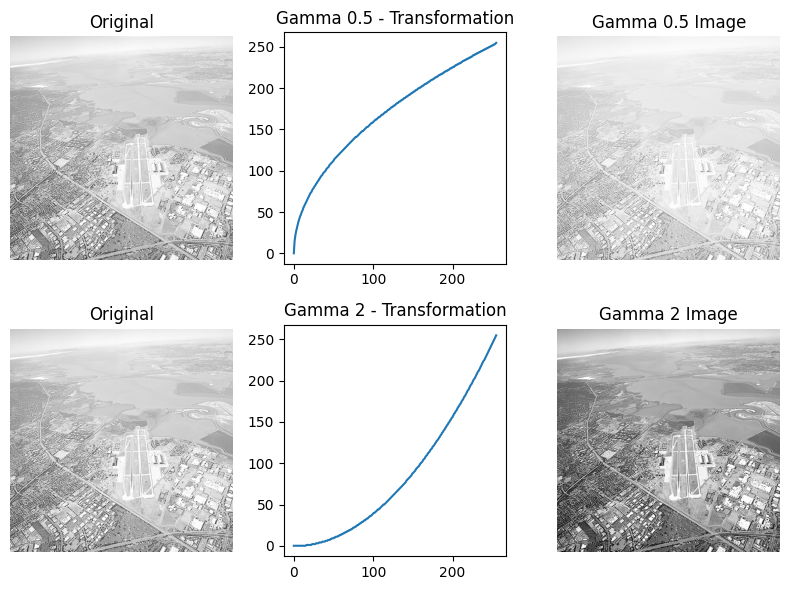

In [4]:
f = cv.imread("images/runway.png", cv.IMREAD_GRAYSCALE)

if f is None:
    raise ValueError("Image not loaded")

# Gamma 0.5 (brighten)
gamma = 0.5
t1 = np.array([(i/255.0) ** (gamma) * 255 for i in np.arange(0,256)]).astype(np.uint8)
g1 = cv.LUT(f, t1)

# Gamma 2 (darken)
gamma = 2
t2 = np.array([(i/255.0) ** (gamma) * 255 for i in np.arange(0,256)]).astype(np.uint8)
g2 = cv.LUT(f, t2)

fig, ax = plt.subplots(2,3, figsize=(8,6))

ax[0, 0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0, 0].set_title("Original")

ax[1, 0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[1, 0].set_title("Original")

x = np.arange(0, 256)

for a in ax.flatten():
    a.axis('off')

ax[0, 1].plot(x, t1)
ax[0, 1].set_title("Gamma 0.5 - Transformation")
ax[0, 1].axis('on')

ax[0, 2].imshow(g1, cmap='gray', vmin=0, vmax=255)
ax[0, 2].set_title("Gamma 0.5 Image")

ax[1, 1].plot(x, t2)
ax[1, 1].set_title("Gamma 2 - Transformation")
ax[1, 1].axis('on')

ax[1, 2].imshow(g2, cmap='gray', vmin=0, vmax=255)
ax[1, 2].set_title("Gamma 2 Image")

plt.tight_layout()
plt.show()

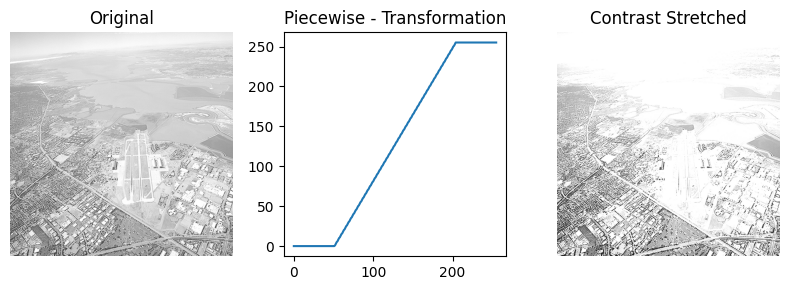

In [21]:
f = cv.imread("images/runway.png", cv.IMREAD_GRAYSCALE)

if f is None:
    raise ValueError("Image not loaded")

# As r is in range [0,1] we have to multiply by 255
r1 = int(0.2 * 255)
r2 = int(0.8 * 255)

# Build LUT
t = np.zeros(256, dtype=np.uint8)

for i in range(256):
    if i < r1:
        t[i] = 0
    elif i <= r2:
        t[i] = int((i - r1) / (r2 - r1) * 255)
    else:
        t[i] = 255

# Apply transformation
g = cv.LUT(f, t)

# Plot
fig, ax = plt.subplots(1, 3, figsize=(8,3))

ax[0].imshow(f, cmap='gray', vmin=0, vmax=255)
ax[0].set_title("Original")

ax[1].plot(np.arange(0, 256), t)
ax[1].set_title("Piecewise - Transformation")

ax[2].imshow(g, cmap='gray', vmin=0, vmax=255)
ax[2].set_title("Contrast Stretched")

for a in ax.flatten():
    a.axis('off')

ax[1].axis('on')

plt.tight_layout()
plt.show()

Question 2

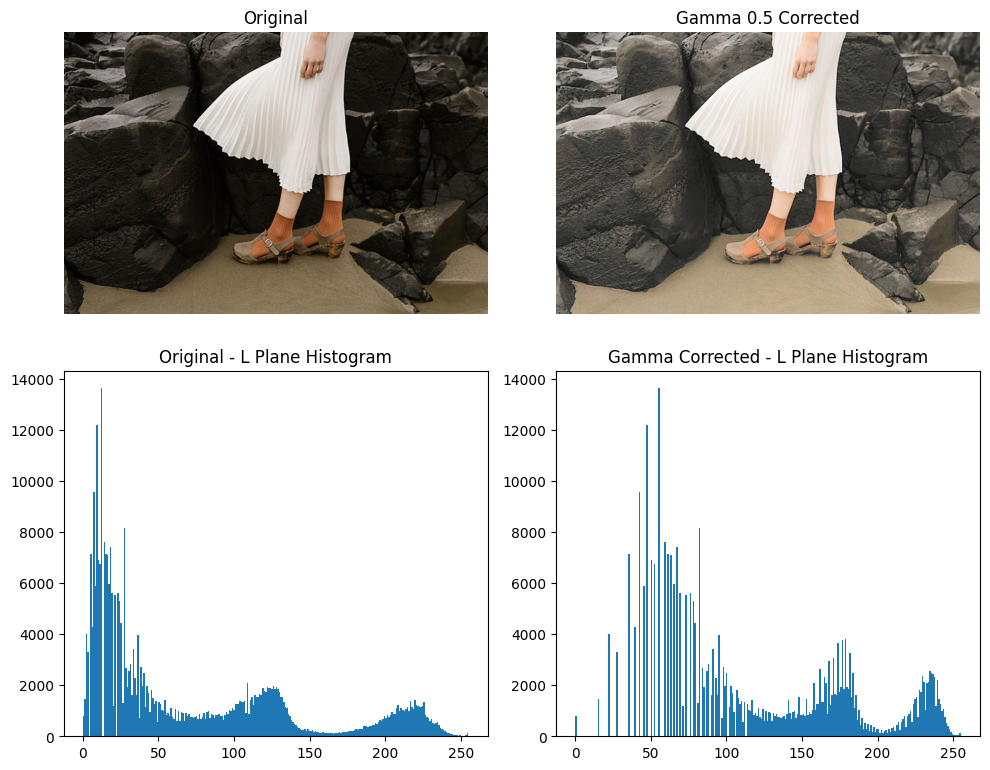

In [20]:
# Read image
img = cv.imread("images/highlights_and_shadows.jpg")   # change path
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert to LAB
lab = cv.cvtColor(img, cv.COLOR_RGB2LAB)

L, a, b = cv.split(lab)

# Choose gamma
gamma = 0.5   # <1 brighten, >1 darken

L_new = (np.power(L / 255.0, gamma) * 255).astype(np.uint8)

# Merge channels
lab_new = cv.merge([L_new, a, b])

# Convert back to RGB
img_new = cv.cvtColor(lab_new, cv.COLOR_LAB2RGB)

# -------------------------
# Plot images
# -------------------------
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

ax[0,0].imshow(img)
ax[0,0].set_title("Original")

ax[0,1].imshow(img_new)
ax[0,1].set_title(f"Gamma {gamma} Corrected")

# -------------------------
# Histograms
# -------------------------
ax[1,0].hist(L.ravel(), bins=256, range=(0,255))
ax[1,0].set_title("Original - L Plane Histogram")

ax[1,1].hist(L_new.ravel(), bins=256, range=(0,255))
ax[1,1].set_title("Gamma Corrected - L Plane Histogram")

for a in ax.flatten():
    a.axis('off')

# Keep histogram axes visible
ax[1,0].axis('on')
ax[1,1].axis('on')

plt.tight_layout()
plt.show()

Question 3

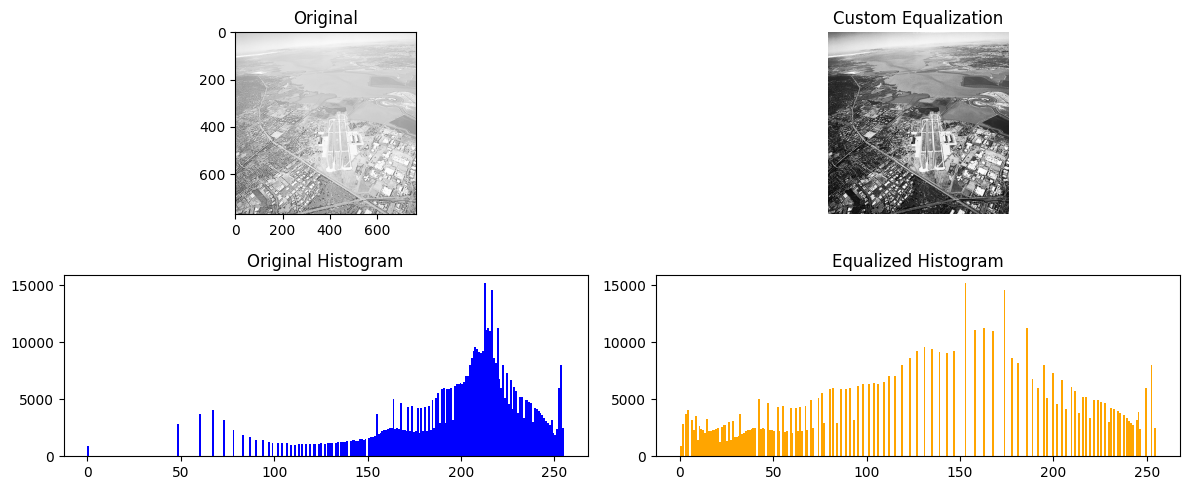

In [19]:
def hist_equalization(img):
    # Flatten image to 1D
    flat = img.flatten()

    # Step 1: Compute histogram
    hist = np.zeros(256, dtype=int)
    for pixel in flat:
        hist[pixel] += 1

    # Step 2: Normalize histogram (PDF)
    total_pixels = img.shape[0] * img.shape[1]
    pdf = hist / total_pixels

    # Step 3: Compute CDF
    cdf = np.cumsum(pdf)

    # Step 4: Map old values → new values
    equalized_values = np.floor(255 * cdf).astype(np.uint8)

    # Step 5: Replace pixels
    equalized_img = equalized_values[flat]

    # Reshape back to original image shape
    equalized_img = equalized_img.reshape(img.shape)

    return equalized_img

f = cv.imread("images/runway.png", cv.IMREAD_GRAYSCALE)

if f is None:
    raise ValueError("Image not loaded")

eq_img = hist_equalization(f)

fig, ax = plt.subplots(2, 2, figsize=(12, 5))

ax[0, 0].set_title('Original')
ax[0, 0].imshow(f, cmap='gray')

ax[1, 0].set_title('Original Histogram')
ax[1, 0].hist(f.ravel(), color='blue', bins=256, range=(0,255))

ax[0, 1].set_title('Custom Equalization')
ax[0, 1].imshow(eq_img, cmap='gray')
ax[0, 1].axis('off')

ax[1, 1].set_title('Equalized Histogram')
ax[1, 1].hist(eq_img.ravel(), color='orange', bins=256, range=(0,255))

plt.tight_layout()
plt.show()

Question 4

Otsu Threshold = 98.0


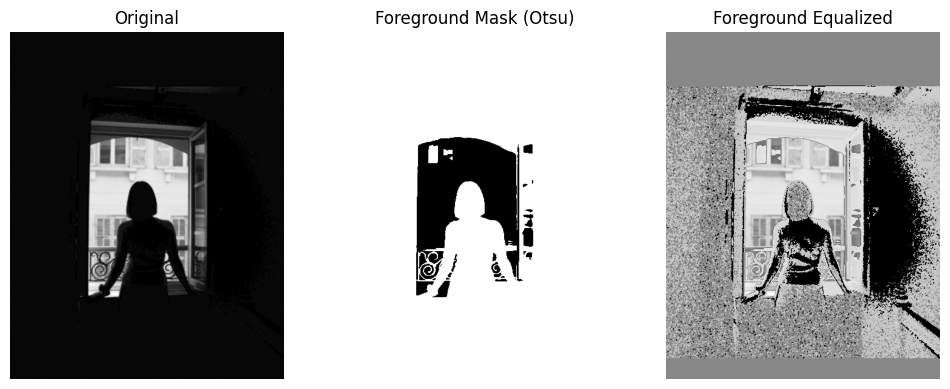

In [22]:
f = cv.imread('images/figure3.png', cv.IMREAD_GRAYSCALE)
if f is None:
    raise ValueError("Image not loaded")

# Otsu threshold
ret, mask = cv.threshold(f, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

print("Otsu Threshold =", ret)

# Equalize whole image first
equalized = cv.equalizeHist(f)

# Replace ONLY foreground pixels
result = f.copy()
result[mask == 255] = equalized[mask == 255]

fig, ax = plt.subplots(1, 3, figsize=(12, 5))

ax[0].set_title('Original')
ax[0].imshow(f, cmap='gray')

ax[1].set_title('Foreground Mask (Otsu)')
ax[1].imshow(mask, cmap='gray')

ax[2].set_title('Foreground Equalized')
ax[2].imshow(result, cmap='gray')

for a in ax:
    a.axis('off')

plt.show()

Question 5

In [25]:
# Define Gaussian kernel function
def gaussian_func(x, y, sigma):
    return (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))

def gaussian_kernel(size, sigma):
    ax = np.arange(-(size//2), size//2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = gaussian_func(xx, yy, sigma)
    return kernel / np.sum(kernel) # Normalize to sum to 1

kernel_5x5 = gaussian_kernel(5, 2)
print(kernel_5x5)
print("Sum:", np.sum(kernel_5x5))  

[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]
Sum: 0.9999999999999998


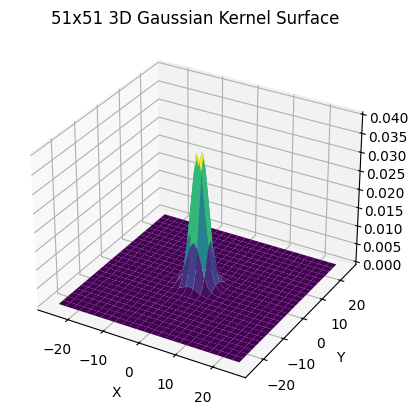

In [27]:
# Create grid
x = np.arange(-25, 26)   # centered at 0 (better for Gaussian)
y = np.arange(-25, 26)

X, Y = np.meshgrid(x, y)

# Generate kernel
kernel_51 = gaussian_kernel(51, 2)

# Plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, kernel_51, cmap="viridis")

ax.set_title("51x51 3D Gaussian Kernel Surface")
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

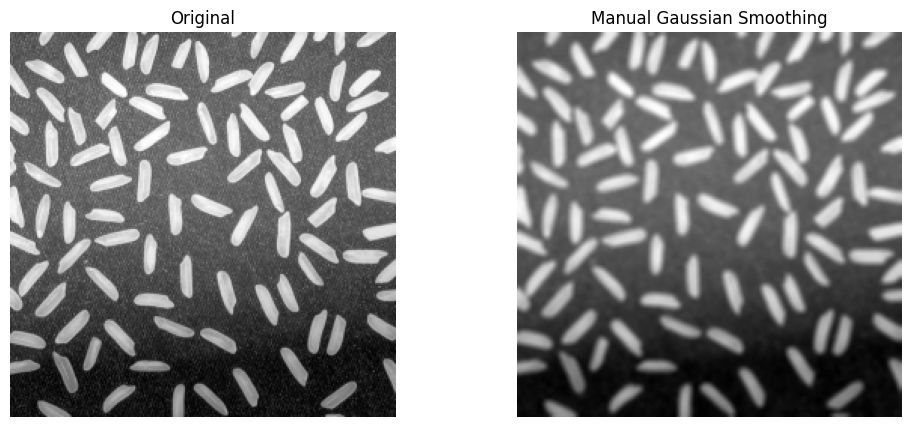

In [28]:
img = cv.imread('images/rice.png', cv.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Image not loaded")

kernel = gaussian_kernel(5, 2)

# Apply convolution
smoothed_manual = cv.filter2D(img, -1, kernel)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_title('Original')
ax[0].imshow(img, cmap='gray')

ax[1].set_title('Manual Gaussian Smoothing')
ax[1].imshow(smoothed_manual, cmap='gray')

for a in ax:
    a.axis('off')

plt.show()

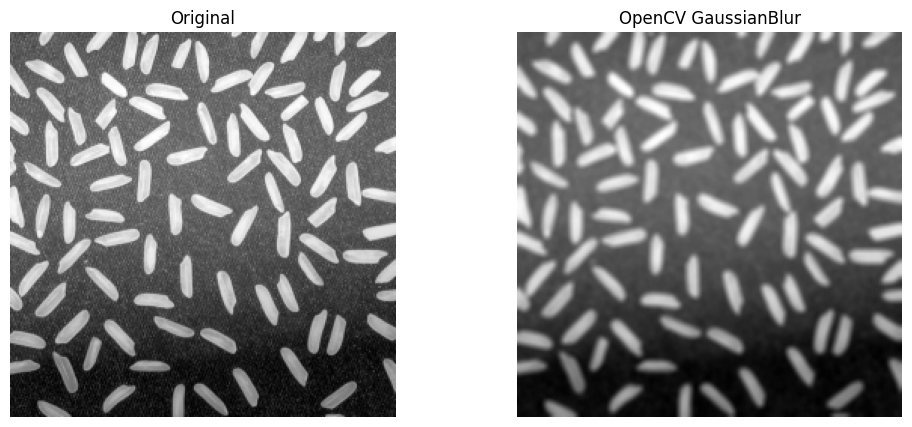

In [29]:
smoothed_cv = cv.GaussianBlur(img, (5, 5), sigmaX=2)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_title('Original')
ax[0].imshow(img, cmap='gray')

ax[1].set_title('OpenCV GaussianBlur')
ax[1].imshow(smoothed_cv, cmap='gray')

for a in ax:
    a.axis('off')

plt.show()

Question 6

In [30]:
def fopd_gaussian_kernels(size, sigma):
    ax = np.arange(-(size//2), size//2 + 1)
    xx, yy = np.meshgrid(ax, ax)

    G = gaussian_func(xx, yy, sigma)

    Gx = -(xx / sigma**2) * G
    Gy = -(yy / sigma**2) * G

    # Normalize
    Gx = Gx / np.sum(np.abs(Gx))
    Gy = Gy / np.sum(np.abs(Gy))

    return Gx, Gy

Gx, Gy = fopd_gaussian_kernels(5, 2)

print("Gx:\n", Gx)
print("Gy:\n", Gy)

Gx:
 [[ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.07275825  0.05293131 -0.         -0.05293131 -0.07275825]
 [ 0.06420893  0.04671172 -0.         -0.04671172 -0.06420893]
 [ 0.04413011  0.03210446 -0.         -0.03210446 -0.04413011]]
Gy:
 [[ 0.04413011  0.06420893  0.07275825  0.06420893  0.04413011]
 [ 0.03210446  0.04671172  0.05293131  0.04671172  0.03210446]
 [-0.         -0.         -0.         -0.         -0.        ]
 [-0.03210446 -0.04671172 -0.05293131 -0.04671172 -0.03210446]
 [-0.04413011 -0.06420893 -0.07275825 -0.06420893 -0.04413011]]


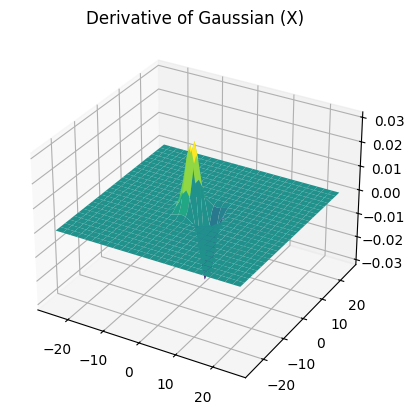

In [32]:

Gx, Gy = fopd_gaussian_kernels(51, 2)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(np.arange(-25, 26), np.arange(-25, 26))
ax.plot_surface(X, Y, Gx, cmap="viridis")

ax.set_title("Derivative of Gaussian (X)")
plt.show()

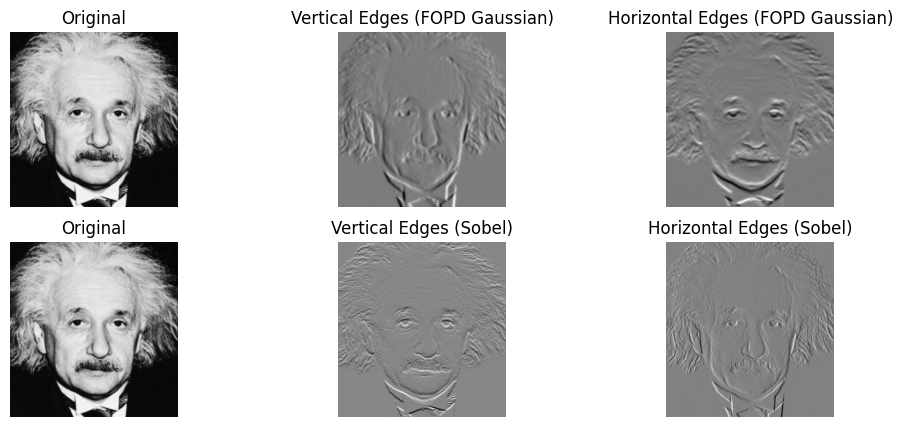

In [33]:
img = cv.imread('images/einstein.png', cv.IMREAD_GRAYSCALE)

Gx, Gy = fopd_gaussian_kernels(51, 2)

Ix = cv.filter2D(img, cv.CV_64F, Gx)
Iy = cv.filter2D(img, cv.CV_64F, Gy)

sobel_x = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
sobel_y = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])

im_x = cv.filter2D(img, cv.CV_64F, sobel_x)
im_y = cv.filter2D(img, cv.CV_64F, sobel_y)

fig, ax = plt.subplots(2, 3, figsize=(12, 5))

ax[0, 0].set_title('Original')
ax[0, 0].imshow(img, cmap='gray')

ax[0, 1].set_title('Vertical Edges (FOPD Gaussian)')
ax[0, 1].imshow(Ix, cmap='gray')

ax[0, 2].set_title('Horizontal Edges (FOPD Gaussian)')
ax[0, 2].imshow(Iy, cmap='gray')

ax[1, 0].set_title('Original')
ax[1, 0].imshow(img, cmap='gray')

ax[1, 1].set_title('Vertical Edges (Sobel)')
ax[1, 1].imshow(im_x, cmap='gray')

ax[1, 2].set_title('Horizontal Edges (Sobel)')
ax[1, 2].imshow(im_y, cmap='gray')


for a in ax.flatten():
    a.axis('off')

plt.show()

Question 7

Image im01.png: NN SSD = 137.21, BL SSD = 115.69
Image im02.png: NN SSD = 26.69, BL SSD = 18.48
Image im03.png: NN SSD = 72.18, BL SSD = 50.25
Image taylor.jpg: NN SSD = 239.49, BL SSD = 224.90


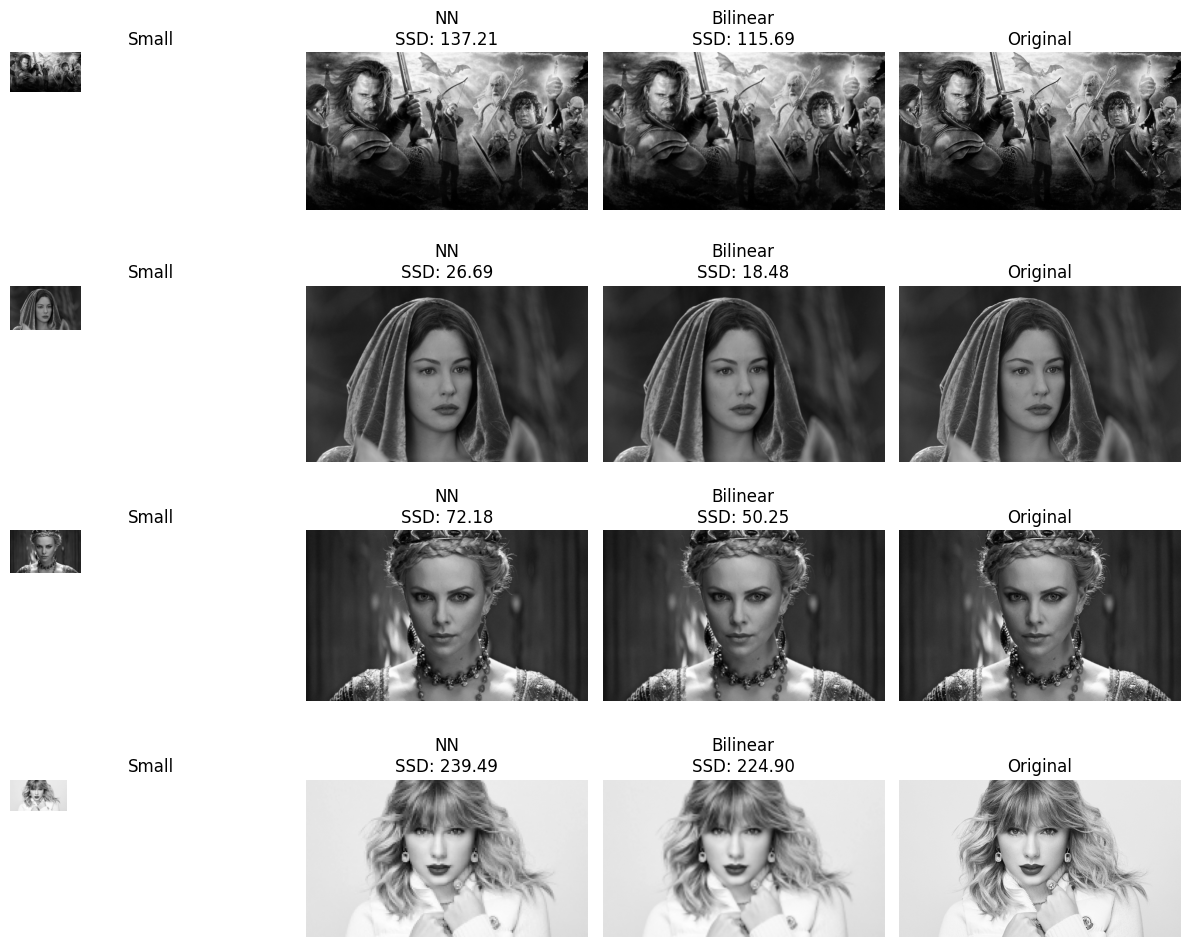

In [39]:
# 1. Nearest Neighbor Scaling / Bilinear Interpolation
def zoom_image(img, scale, method='nearest'):
    """
    Zoom image using nearest or bilinear interpolation (OpenCV-like behavior)

    Parameters:
        img    : input grayscale image
        scale  : zoom factor (0 < scale <= 10)
        method : 'nearest' or 'bilinear'

    Returns:
        zoomed image
    """

    h, w = img.shape
    new_h, new_w = int(h * scale), int(w * scale)

    zoomed = np.zeros((new_h, new_w), dtype=np.float32)

    for i in range(new_h):
        for j in range(new_w):

            # pixel-center aligned
            x = (i + 0.5) / scale - 0.5
            y = (j + 0.5) / scale - 0.5

            if method == 'nearest':
                # nearest neighbor rounding
                xi = int(np.floor(x + 0.5))
                yi = int(np.floor(y + 0.5))

                # Clamp to valid range
                xi = np.clip(xi, 0, h - 1)
                yi = np.clip(yi, 0, w - 1)

                zoomed[i, j] = img[xi, yi]

            elif method == 'bilinear':
                # Floor indices
                x1 = int(np.floor(x))
                y1 = int(np.floor(y))

                # Neighbor indices
                x2 = min(x1 + 1, h - 1)
                y2 = min(y1 + 1, w - 1)

                # Clamp base indices
                x1 = max(x1, 0)
                y1 = max(y1, 0)

                # Distances
                dx = x - x1
                dy = y - y1

                # Pixel values
                I11 = img[x1, y1]
                I21 = img[x2, y1]
                I12 = img[x1, y2]
                I22 = img[x2, y2]

                # Bilinear interpolation
                value = (
                    (1 - dx) * (1 - dy) * I11 +
                    dx * (1 - dy) * I21 +
                    (1 - dx) * dy * I12 +
                    dx * dy * I22
                )

                zoomed[i, j] = value

            else:
                raise ValueError("Method must be 'nearest' or 'bilinear'")

    return zoomed.astype(np.uint8)

# 2. SSD Calculation
def normalized_ssd(img1, img2):
    h = min(img1.shape[0], img2.shape[0])
    w = min(img1.shape[1], img2.shape[1])

    img1_crop = img1[:h, :w].astype(np.float32)
    img2_crop = img2[:h, :w].astype(np.float32)

    diff = img1_crop - img2_crop
    return np.mean(diff ** 2)

image_ids = [
    ('im01small.png', 'im01.png'),
    ('im02small.png', 'im02.png'),
    ('im03small.png', 'im03.png'),
    ('taylor_small.jpg', 'taylor.jpg')
]

fig, ax = plt.subplots(4, 4, figsize=(12, 10))

for row, (small_id, large_id) in enumerate(image_ids):

    # ---- Load images ----
    small = cv.imread(f'images/Q7/{small_id}', cv.IMREAD_GRAYSCALE)
    large = cv.imread(f'images/Q7/{large_id}', cv.IMREAD_GRAYSCALE)

    if small is None or large is None:
        raise ValueError(f"Image {large_id} not loaded")

    # ---- Compute scale ----
    h_small, w_small = small.shape
    h_large, w_large = large.shape

    scale_h = h_large / h_small
    scale_w = w_large / w_small
    scale = (scale_h + scale_w) / 2

    # ---- Zoom ----
    nn_img = zoom_image(small, scale, method='nearest')
    bl_img = zoom_image(small, scale, method='bilinear')

    # ---- SSD ----
    ssd_nn = normalized_ssd(nn_img, large)
    ssd_bl = normalized_ssd(bl_img, large)

    print(f"Image {large_id}: NN SSD = {ssd_nn:.2f}, BL SSD = {ssd_bl:.2f}")

    # ---- Plot (row-wise) ----
    # Small
    ax[row, 0].imshow(small, cmap='gray')
    ax[row, 0].set_title('Small')
    ax[row, 0].set_xlim(0, w_large)
    ax[row, 0].set_ylim(h_large, 0)

    # NN
    ax[row, 1].imshow(nn_img, cmap='gray')
    ax[row, 1].set_title(f'NN\nSSD: {ssd_nn:.2f}')
    ax[row, 1].set_xlim(0, w_large)
    ax[row, 1].set_ylim(h_large, 0)

    # Bilinear
    ax[row, 2].imshow(bl_img, cmap='gray')
    ax[row, 2].set_title(f'Bilinear\nSSD: {ssd_bl:.2f}')
    ax[row, 2].set_xlim(0, w_large)
    ax[row, 2].set_ylim(h_large, 0)

    # Large
    ax[row, 3].imshow(large, cmap='gray')
    ax[row, 3].set_title('Original')
    ax[row, 3].set_xlim(0, w_large)
    ax[row, 3].set_ylim(h_large, 0)

# ---- Clean axes ----
for a in ax.flatten():
    a.axis('off')

plt.tight_layout()
plt.show()